# Building Speech-To-Text Transformers

Importing the dataset

In [24]:
import io

import soundfile as sf
from datasets import Audio, load_dataset

dataset = load_dataset(
    "m-aliabbas/idrak_timit",
    split="train",
)
dataset = dataset.cast_column("audio", Audio(decode=False))


How does the dataset look like?

In [25]:

from IPython.display import Audio

# Get first item as sample
sample = next(iter(dataset))
waveform, sample_rate = sf.read(io.BytesIO(sample["audio"]["bytes"])) # type: ignore

print("Waveform:", waveform.shape)
audio_length_s = waveform.size / sample_rate
print("Length:", audio_length_s)
print("Rate:", sample_rate)
print("Transcription:", sample["transcription"])# type: ignore
Audio(waveform, rate=sample_rate)

Waveform: (43930,)
Length: 2.745625
Rate: 16000
Transcription: rich purchased several signed lithographs


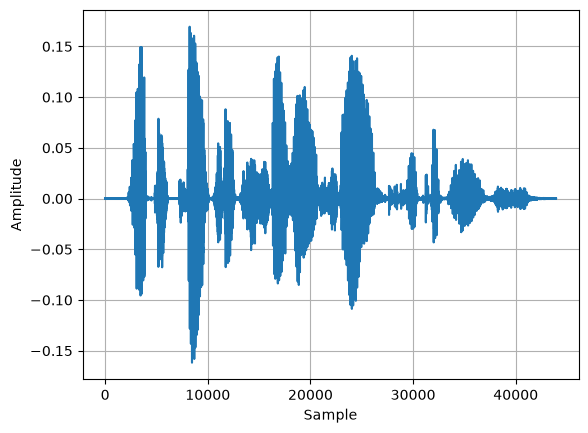

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(waveform)
plt.grid(True, which="both")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [27]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)

True
2.13.0+cu130
